# Progetto di programmazione di applicazioni data intensive

L'obbiettivo del progetto è realizzare un modello di regressione capace di stimare il valore economico "centrale" delle abitazioni (median_house_value) all'interno di diversi isolati della California. Questo strumento permetterebbe a un'agenzia immobiliare di automatizzare le stime dei prezzi, riducendo i tempi di vendita e fornendo un supporto oggettivo nelle decisioni commerciali.

In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("File disponibili:", os.listdir(path))

data = pd.read_csv(os.path.join(path, "housing.csv"))
data.head()

File disponibili: ['housing.csv']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
data.shape

(20640, 10)

# Analisi del Dataset: California Housing Prices

Il dataset scelto è il **California Housing Prices** (reperito da Kaggle), che contiene informazioni dal censimento della California del 1990. Il dataset contiene **20.640 istanze** e **10 variabili**.

---

### Descrizione delle variabili

|  | Variabile | Descrizione |
| :--- | :--- | :--- |
| **1** | `longitude` | Misura di quanto una casa sia a ovest; un valore più alto indica una posizione più a ovest. |
| **2** | `latitude` | Misura di quanto una casa sia a nord; un valore più alto indica una posizione più a nord. |
| **3** | `housing_median_age` | Età media di una casa all'interno di un isolato (*block*); un numero più basso indica un edificio più recente. |
| **4** | `total_rooms` | Numero totale di stanze all'interno di un isolato. |
| **5** | `total_bedrooms` | Numero totale di camere da letto all'interno di un isolato. |
| **6** | `population` | Numero totale di persone residenti all'interno di un isolato. |
| **7** | `households` | Numero totale di nuclei familiari (gruppi di persone che risiedono in un'unica unità abitativa) per isolato. |
| **8** | `median_income` | Reddito medio dei nuclei familiari all'interno dell'isolato (misurato in decine di migliaia di dollari USA). |
| **9** | `median_house_value` | Valore medio della casa per i nuclei familiari all'interno dell'isolato (misurato in dollari USA). |
| **10** | `ocean_proximity` | Posizione della casa rispetto all'oceano/mare. |

---

### Suddivisione delle variabili per il modello

* **Variabile Target ($y$):** `median_house_value` (valore continuo).
* **Feature ($X$):** Il dataset include **9 predittori**, così suddivisi:
  * **Coordinate geografiche:** `longitude`, `latitude`
  * **Dati demografici:** `population`, `median_income`
  * **Caratteristiche degli immobili:** `total_rooms`, `total_bedrooms`, `housing_median_age`, `households`
  * **Variabile categorica:** `oceanProximity`

# Analisi esplorativa del dataset

## Statistiche descrittive

La tabella seguente riporta le principali misure di tendenza centrale e dispersione
per tutte le variabili numeriche del dataset, inclusi media, deviazione standard,
valore minimo, massimo e quartili.

In [3]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


## Analisi dei valori nulli

É fondamentale verificare la presenza
di valori mancanti nel dataset :

Per ogni colonna viene calcolato il numero assoluto di valori nulli e la relativa
percentuale sul totale delle osservazioni.
Si nota che l'unica variabile con dati mancanti è `total_bedrooms`, con **207 valori nulli**,
pari a circa l'**1%** del totale delle osservazioni (20.640 righe).

Trattandosi di una percentuale molto bassa, nel preprocessing si potrà scegliere
tra due strategie:
- **Eliminazione** delle righe con valore mancante, con perdita minima di dati
- **Imputazione** con la mediana della colonna

In [4]:
null_df = pd.DataFrame({
    "valori_nulli": data.isnull().sum(),
    "percentuale": (data.isnull().sum() / len(data) * 100).round(2)
})
null_df[null_df["valori_nulli"] > 0]

,valori_nulli,percentuale
total_bedrooms,207,1.0


## Analisi della variabile categorica: ocean_proximity

La variabile `ocean_proximity` indica la posizione geografica delle abitazioni
rispetto all'oceano ed è l'unica feature categorica del dataset. Prima di procedere
con la codifica nel preprocessing, è utile analizzarne la distribuzione per
identificare eventuali categorie rare o assenti.

Dal grafico a barre e dal grafico a torta emergono le seguenti frequenze:

| Categoria | Descrizione |
|---|---|
| `<1H OCEAN` | entro un'ora dall'oceano — categoria più frequente |
| `INLAND` | zone interne, lontane dalla costa |
| `NEAR OCEAN` | in prossimità dell'oceano |
| `NEAR BAY` | vicino alla baia di San Francisco |
| `ISLAND` | isola — **assente nel dataset** |

La categoria **`ISLAND`** non compare in nessuna osservazione del dataset, nonostante
sia teoricamente prevista. Di conseguenza, nel preprocessing non sarà necessario
codificarla: le tecniche di encoding (es. one-hot encoding) produrranno solo
**4 variabili dummy** anziché 5, evitando l'introduzione di una colonna
interamente a zero.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

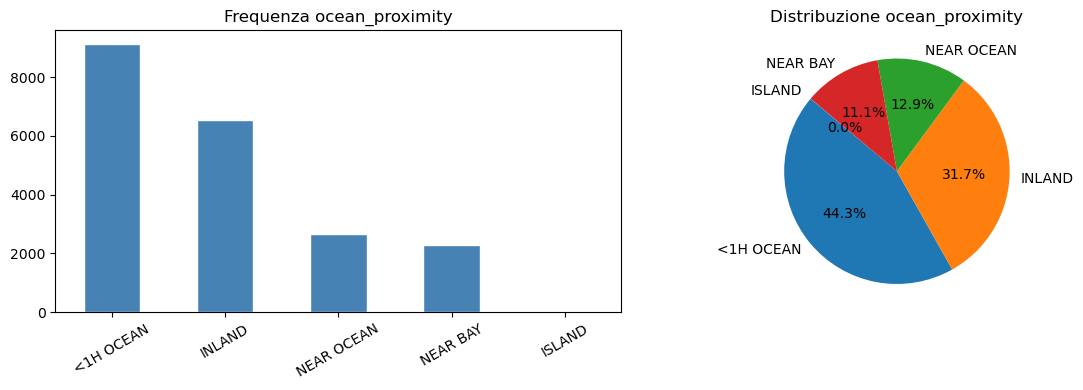

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = data["ocean_proximity"].value_counts()

# Barre
counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Frequenza ocean_proximity")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Torta
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Distribuzione ocean_proximity")

plt.tight_layout()
plt.show()

## Istogrammi delle variabili numeriche

Questa cella genera una griglia di istogrammi per visualizzare la distribuzione di tutte le variabili numeriche presenti nel dataset. Gli istogrammi permettono di valutare rapidamente la forma della distribuzione, identificare eventuali asimmetrie, valori anomali e intervalli di variazione per ciascuna variabile continua.

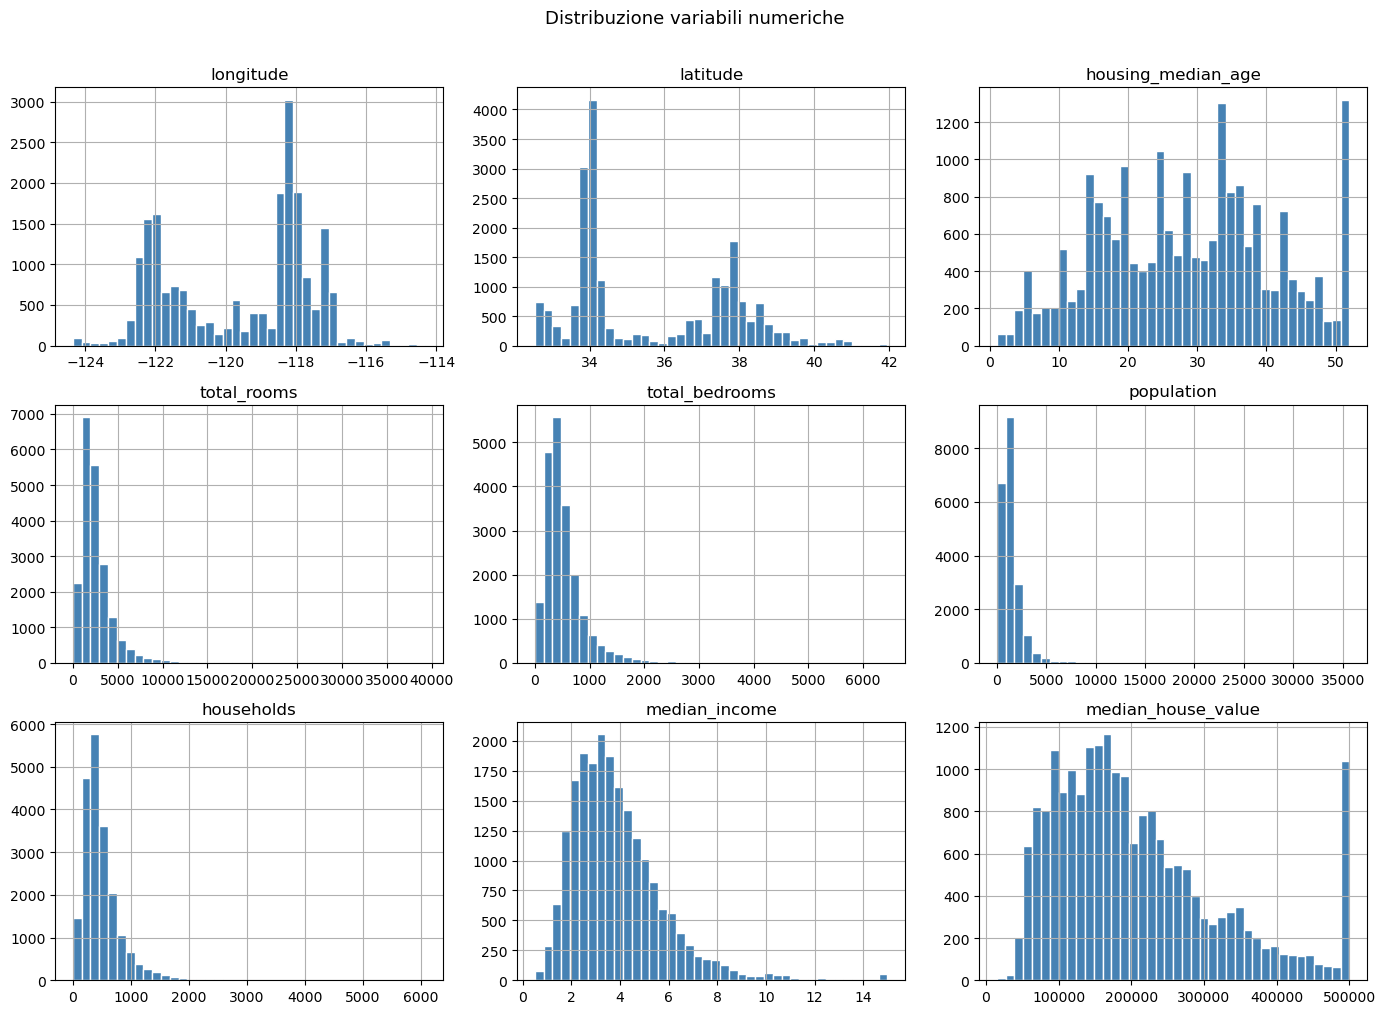

In [7]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()

data[num_cols].hist(bins=40, figsize=(14, 10), color="steelblue",
                   edgecolor="white", layout=(3, 3))
plt.suptitle("Distribuzione variabili numeriche", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Matrice di correlazione

Questa cella calcola e visualizza la matrice di correlazione tra tutte le variabili numeriche del dataset, evidenziando le relazioni lineari tra le variabili. In particolare si nota la forte correlazione tra la variabile `median_income` e `median_house_value`. 

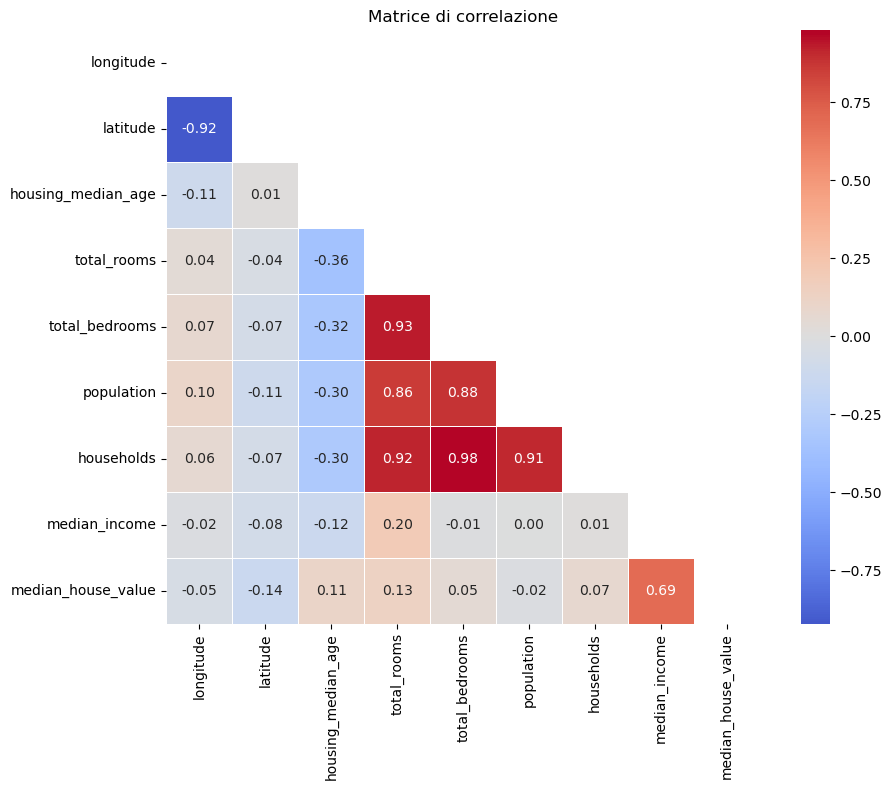

median_house_value    1.00
median_income         0.69
total_rooms           0.13
housing_median_age    0.11
households            0.07
total_bedrooms        0.05
population           -0.02
longitude            -0.05
latitude             -0.14
Name: median_house_value, dtype: float64


In [8]:
corr = data[num_cols].corr().round(2)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

# Correlazioni col target ordinate
print(corr["median_house_value"].sort_values(ascending=False))

## Visualizzo graficamente la relazione tra median_income e median_house_value

Da heatmap noto grossa correlazione tra `median_income` e `median_house_value`. In questo grafico si può vedere graficamente che all'aumentare di median_income aumenta pure median_house value. Quindi la variabile indipendente median_income è il predittore più rilevante nel nostro modello di predizione.


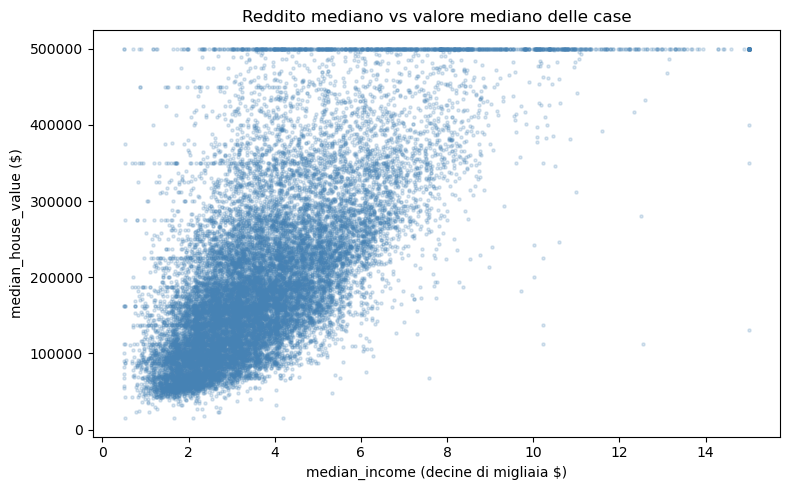

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(data["median_income"], data["median_house_value"],
            alpha=0.2, s=5, color="steelblue")
plt.xlabel("median_income (decine di migliaia $)")
plt.ylabel("median_house_value ($)")
plt.title("Reddito mediano vs valore mediano delle case")
plt.tight_layout()
plt.show()

Dal grafico si nota anche che la linea orizzontale di dati schiacciati a 500000 (`median_house_value`) è  un cap artificiale: chi ha raccolto i dati ha deciso di troncare tutti i valori superiori a quella soglia, registrandoli tutti come 500001 (questo si nota anche dal fatto che ci sono 965 righe a esattamente 500.001$). Bisogna tenere conto della distorsione che creano questi dati poiché rappresentano quasi il 5% dell'intero dataset; pertanto, andranno rimossi durante la fase di preprocessing.

In [10]:
value_500k = data[data['median_house_value'] == 500000]
print(f"Case esattamente a 500000: {len(value_500k)}")

value_over_500k = data[data['median_house_value'] > 500000]
print(f"Case sopra 500000: {len(value_over_500k)}") 

value_501k = data[data['median_house_value'] == 500001]
print(f"Case esattamente a 500001: {len(value_501k)}")

max_value = data['median_house_value'].max()
print(f"\nValore massimo assoluto: {max_value}")

high_values = data[data['median_house_value'] > 500000]
print(f"\nValori > 500.000: {len(high_values)} ({len(high_values)/len(data)*100:.2f}%)")
print(f"Range: {high_values['median_house_value'].min():.0f} - {high_values['median_house_value'].max():.0f}")

Case esattamente a 500000: 27
Case sopra 500000: 965
Case esattamente a 500001: 965

Valore massimo assoluto: 500001.0

Valori > 500.000: 965 (4.68%)
Range: 500001 - 500001


## Multicollinearità tra le variabili
Dalla matrice di correlazione si puo notare una forte correlazione tra alcune feature del dataset che descrivono tutte la "dimensione" di un blocco
abitativo — `total_rooms`, `total_bedrooms`, `households` e `population` — (quindi lecito aspettarsi che siano fortemente correlate tra loro).

La scatter matrix conferma questa ipotesi:
le variabili presentano correlazioni molto elevate, un fenomeno noto come
**multicollinearità**. Questo può rendere instabili i coefficienti della
regressione lineare, poiché il modello fatica a distinguere il contributo
individuale di ciascuna feature. Attenueremo questo problema con la regressione Ridge che grazie alla
regolarizzazione L2 penalizza i coefficienti
grandi rendendoli più stabili.

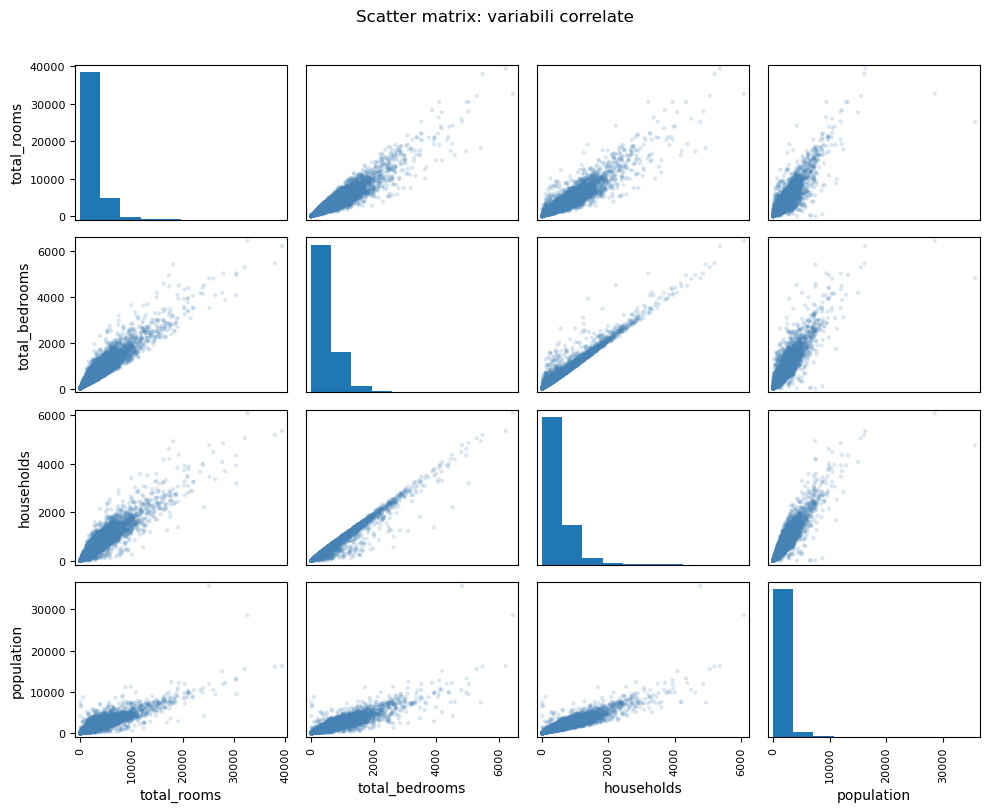

                total_rooms  total_bedrooms  households  population
total_rooms            1.00            0.93        0.92        0.86
total_bedrooms         0.93            1.00        0.98        0.88
households             0.92            0.98        1.00        0.91
population             0.86            0.88        0.91        1.00


In [11]:
# Variabili sospettate di multicollinearità
multicoll_cols = ["total_rooms", "total_bedrooms", "households", "population"]

pd.plotting.scatter_matrix(data[multicoll_cols], figsize=(10, 8), 
                           alpha=0.2, diagonal="hist", color="steelblue")
plt.suptitle("Scatter matrix: variabili correlate", y=1.01)
plt.tight_layout()
plt.show()

print(data[multicoll_cols].corr().round(2))

## Mappa geografica: distribuzione del valore delle case

Sfruttando le coordinate geografiche (`longitude` e `latitude`) presenti nel dataset,
è possibile visualizzare la distribuzione spaziale del valore delle case in California,
usando il colore per rappresentare `median_house_value` (scala plasma: viola = basso,
giallo = alto).

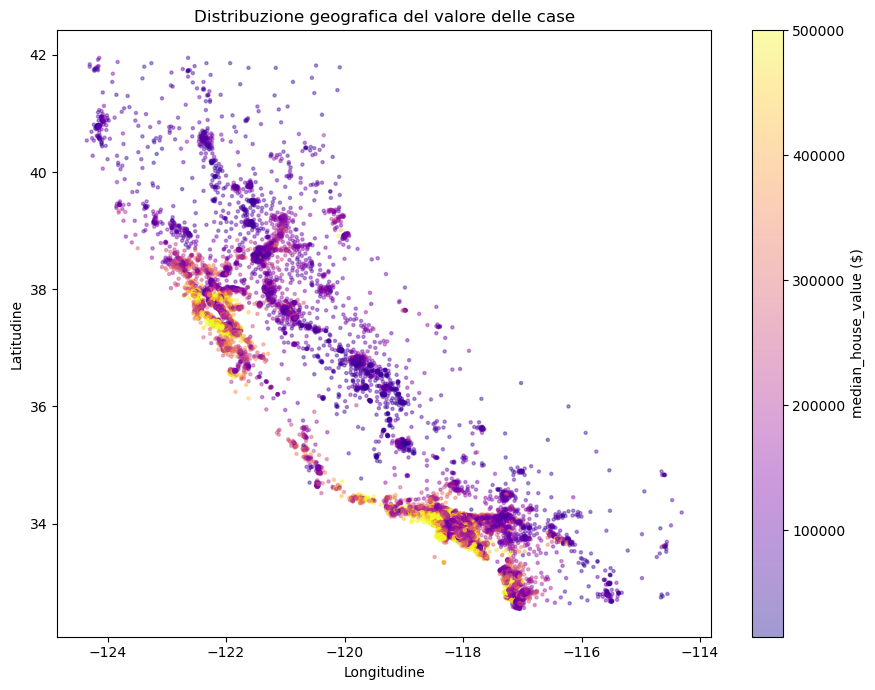

In [12]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(data["longitude"], data["latitude"],
                 c=data["median_house_value"], cmap="plasma",
                 alpha=0.4, s=5)
plt.colorbar(sc, label="median_house_value ($)")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title("Distribuzione geografica del valore delle case")
plt.tight_layout()
plt.show()

# Preprocessing



## Encoding della variabile categorica: ocean_proximity

Poiché i modelli di machine learning non gestiscono direttamente variabili
categoriche, `ocean_proximity` viene convertita tramite **one-hot encoding**:
ogni categoria diventa una colonna binaria (0/1).

Sebbene la categoria `ISLAND` non compaia in nessuna osservazione del dataset,
pandas la crea comunque come colonna interamente a zero. Viene quindi eliminata
manualmente, ottenendo le seguenti 4 dummy variables:

- `ocean_proximity_<1H OCEAN`
- `ocean_proximity_INLAND`
- `ocean_proximity_NEAR BAY`
- `ocean_proximity_NEAR OCEAN`

La colonna originale `ocean_proximity` viene automaticamente rimossa e sostituita
dalle 4 dummy variables.

In [13]:
data = pd.get_dummies(data, columns=["ocean_proximity"], drop_first=False)
data = data.drop(columns=["ocean_proximity_ISLAND"], errors="ignore")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Gestione dei valori nulli: total_bedrooms

La colonna `total_bedrooms` presenta 207 valori nulli (circa l'1% del dataset).
Si sceglie di imputarli con la **mediana** della colonna, più robusta rispetto
alla media in presenza di distribuzioni asimmetriche come quella di `total_bedrooms`.

Al termine viene verificato che non rimanga alcun valore nullo nel dataset.

In [14]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

print(data.isnull().sum().sum())

0


## Rimozione dei valori cappati: median_house_value

Come osservato nello scatter plot, il dataset presenta un cap artificiale a
500.000$: tutti i valori superiori a tale soglia sono stati troncati durante
la raccolta dei dati, introducendo distorsione nel target.

Queste osservazioni vengono rimosse poiché il loro valore reale è ignoto e
potrebbero portare il modello a sottostimare sistematicamente le case di
fascia alta.

In [15]:
data = data[data["median_house_value"] < 500001]

print(f"Righe rimosse: {20640 - len(data)}")
print(f"Righe rimanenti: {len(data)}")

Righe rimosse: 965
Righe rimanenti: 19675


## Normalizzazione delle feature

Le variabili numeriche vengono normalizzate tramite **MinMaxScaler**, che
trasforma ogni valore nell'intervallo [0, 1]. Questo è necessario per evitare
che feature con scale molto diverse (es. `total_rooms` nell'ordine delle
migliaia vs `median_income` nell'ordine delle decine) dominino il modello.

La normalizzazione viene applicata a tutte le colonne eccetto il target
`median_house_value`, che viene lasciato nella sua scala originale in dollari
per mantenere l'interpretabilità delle predizioni.

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = [col for col in data.columns if col != "median_house_value"]

data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.211155,0.567481,0.784314,0.022331,0.019711,0.008941,0.020395,0.539668,452600.0,0.0,0.0,1.0,0.0
1,0.212151,0.565356,0.392157,0.180503,0.171349,0.067210,0.186842,0.538027,358500.0,0.0,0.0,1.0,0.0
2,0.210159,0.564293,1.000000,0.037260,0.029179,0.013818,0.028783,0.466028,352100.0,0.0,0.0,1.0,0.0
3,0.209163,0.564293,1.000000,0.032352,0.036163,0.015555,0.035691,0.354699,341300.0,0.0,0.0,1.0,0.0
4,0.209163,0.564293,1.000000,0.041330,0.043148,0.015752,0.042270,0.230776,342200.0,0.0,0.0,1.0,0.0


## Suddivisione in training e test set

Il dataset viene diviso in **training set** (80%) e **test set** (20%) tramite
`train_test_split`. Il parametro `random_state=42` garantisce la riproducibilità
della suddivisione. Il test set viene tenuto da parte e utilizzato esclusivamente
per la valutazione finale del modello, simulando dati mai visti in fase di addestramento.

In [17]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["median_house_value"])
y = data["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} righe")
print(f"Test set:     {X_test.shape[0]} righe")

Training set: 15740 righe
Test set:     3935 righe


# Addestramento dei modelli

## Modello 1: Regressione Lineare

Il primo modello addestrato è una **regressione lineare**, che assume una relazione
lineare tra le feature e il target `median_house_value`.

Le metriche di valutazione calcolate sul test set sono:

- **MSE** (Mean Squared Error): errore quadratico medio, penalizza maggiormente
  gli errori grandi
- **RMSE** (Root MSE): radice dell'MSE, espresso nella stessa unità del target ($)
  e quindi più interpretabile
- **R²**: quota di varianza del target spiegata dal modello; un valore vicino a 1
  indica un buon fit
- **Errore relativo**: errore percentuale medio rispetto al valore reale,
  utile per capire di quanto sbaglia il modello in termini relativi

Vengono inoltre analizzati i **coefficienti** del modello per identificare le
variabili più influenti nella predizione: un coefficiente alto (positivo o negativo)
indica che quella feature ha un impatto maggiore sul valore predetto.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Addestramento
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predizione
y_pred = lr.predict(X_test)

# Metriche
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
errore_relativo = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MSE:              {mse:,.2f}")
print(f"RMSE:             {rmse:,.2f}")
print(f"R²:               {r2:.4f}")
print(f"Errore relativo:  {errore_relativo:.2f}%")

MSE:              3,914,036,126.81
RMSE:             62,562.26
R²:               0.6075
Errore relativo:  27.89%


## Interpretazione delle metriche di valutazione del modello

| Metrica | Valore |
|---|---|
| MSE | 3.914.036.126,81 |
| RMSE | 62.562,26 $ |
| R² | 0.6075 |
| Errore relativo | 27.89% |

Il modello lineare spiega il **61% della varianza** (R²) del target, lasciando il
restante 39% non spiegato. In media sbaglia di circa **62.000$** (RMSE) per casa,
corrispondente a un errore relativo del **28%** (Errore relativo) rispetto al valore reale.

Si tratta di un risultato accettabile ma non ottimo, atteso per un modello
così semplice: la regressione lineare non riesce a catturare le relazioni
non lineari tra le feature e il prezzo delle case. Ci si aspetta un
miglioramento significativo con modelli più complessi.

In [19]:
# Coefficienti
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficiente": lr.coef_
}).sort_values("coefficiente", ascending=False)

print("\nCoefficienti del modello:")
print(coef_df.to_string(index=False))


Coefficienti del modello:
                   feature  coefficiente
             median_income  5.413033e+05
                households  4.789119e+05
            total_bedrooms  3.547333e+05
        housing_median_age  4.658215e+04
               total_rooms -1.784162e+05
ocean_proximity_NEAR OCEAN -1.811895e+05
 ocean_proximity_<1H OCEAN -1.847409e+05
  ocean_proximity_NEAR BAY -1.933123e+05
                  latitude -2.105132e+05
    ocean_proximity_INLAND -2.243885e+05
                 longitude -2.428464e+05
                population -1.223625e+06


## Analisi dei coefficienti

I coefficienti indicano l'impatto di ciascuna feature sul valore predetto,
a parità di tutte le altre variabili. Essendo i dati normalizzati, i
coefficienti sono direttamente confrontabili tra loro.

**Feature con impatto positivo** (aumentano il valore predetto):
- `median_income` è il predittore più rilevante in assoluto (coeff. ~541.000),
  confermando quanto emerso dalla matrice di correlazione e dallo scatter plot
- `households` e `total_bedrooms` hanno anch'essi impatto positivo, indicando
  che blocchi più grandi tendono ad avere case di maggior valore
- `housing_median_age` ha impatto positivo ma contenuto

**Feature con impatto negativo** (diminuiscono il valore predetto):
- `population` è la variabile con il coefficiente più negativo (~-1.200.000):
  blocchi molto popolosi tendono ad avere case meno costose
- `longitude` e `latitude` hanno coefficienti negativi elevati, confermando
  che la posizione geografica influenza significativamente il prezzo
- `total_rooms` ha impatto negativo, apparentemente controintuitivo ma spiegabile
  dalla correlazione con `population`: più stanze totali in un blocco significa
  più densità abitativa
- Le dummy di `ocean_proximity` mostrano tutte coefficienti negativi, con
  `INLAND` il più penalizzante

## Visualizzazione del modello: valori reali vs valori predetti

Il grafico mostra la correlazione tra i valori reali e quelli predetti dal modello.
La linea rossa tratteggiata rappresenta la predizione perfetta: più i punti si
avvicinano ad essa, migliore è il modello. La dispersione osservata conferma
l'R² di 0.61.

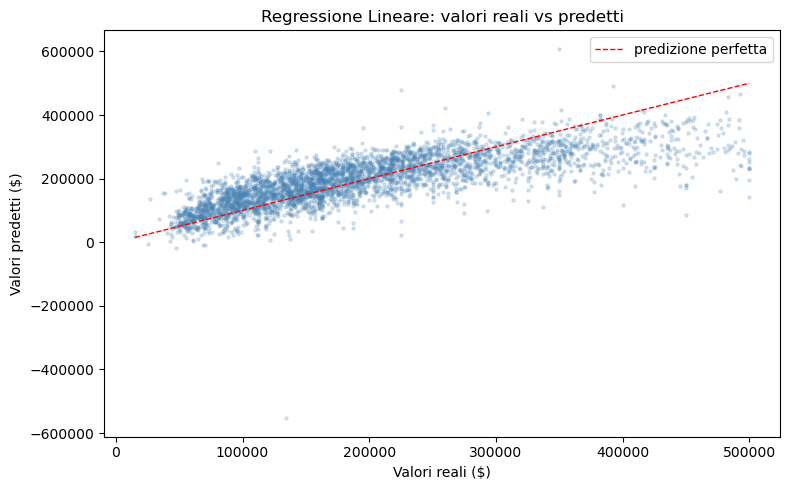

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.2, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linewidth=1, linestyle="--", label="predizione perfetta")
plt.xlabel("Valori reali ($)")
plt.ylabel("Valori predetti ($)")
plt.title("Regressione Lineare: valori reali vs predetti")
plt.legend()
plt.tight_layout()
plt.show()

## Modello 2: Regressione Ridge
La regressione **Ridge** aggiunge alla regressione lineare un termine di
regolarizzazione L2, che penalizza i coefficienti grandi spingendoli verso
zero senza però azzerarli. Questo riduce il rischio di overfitting e gestisce
meglio la multicollinearità tra le feature (come quella tra `total_rooms`,
`total_bedrooms` e `households`).

Il parametro `alpha=1.0` controlla la forza della regolarizzazione:
valori più alti producono coefficienti più piccoli.

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
errore_relativo_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

print(f"MSE:              {mse_ridge:,.2f}")
print(f"RMSE:             {rmse_ridge:,.2f}")
print(f"R²:               {r2_ridge:.4f}")
print(f"Errore relativo:  {errore_relativo_ridge:.2f}%")

MSE:              3,900,635,168.40
RMSE:             62,455.07
R²:               0.6088
Errore relativo:  27.96%


## Interpretazione delle metriche di valutazione del modello

| Metrica | Valore |
|---|---|
| MSE | 3.900.635.168,40 |
| RMSE | 62.455,07 $ |
| R² | 0.6088 |
| Errore relativo | 27.96% |

I risultati sono praticamente identici alla regressione lineare semplice
(R² 0.6088 vs 0.6075, RMSE 62.455$ vs 62.562$), con un miglioramento
minimo. Questo è atteso: Ridge non cambia la struttura del modello ma
stabilizza i coefficienti, ed è utile soprattutto quando c'è forte
multicollinearità tra le feature.

In [22]:
coef_ridge = pd.DataFrame({
    "feature": X.columns,
    "coefficiente": ridge.coef_
}).sort_values("coefficiente", ascending=False)

print("\nCoefficienti Ridge:")
print(coef_ridge.to_string(index=False))


Coefficienti Ridge:
                   feature   coefficiente
             median_income  534783.527221
            total_bedrooms  347572.842868
                households  279990.793959
        housing_median_age   46486.315981
ocean_proximity_NEAR OCEAN  -83094.913147
 ocean_proximity_<1H OCEAN  -88291.709017
  ocean_proximity_NEAR BAY  -95082.177485
    ocean_proximity_INLAND -130082.982781
               total_rooms -143553.091194
                  latitude -197970.495739
                 longitude -231277.112527
                population -843056.043216


## Analisi dei coefficienti

Rispetto alla regressione lineare, i coefficienti Ridge risultano più
contenuti in valore assoluto grazie alla penalizzazione L2:

- `median_income` rimane il predittore positivo più rilevante (~534.000),
  confermando il suo ruolo dominante
- `households` si riduce notevolmente (~280.000 vs ~479.000 nella regressione
  lineare), segno che la regolarizzazione ha attenuato l'effetto della
  multicollinearità con `total_bedrooms`
- `population` rimane la variabile più penalizzante (circa -843.000) ma con un
  valore assoluto inferiore rispetto alla regressione lineare (circa -1.200.000)
- Le dummy di `ocean_proximity` mostrano coefficienti più bilanciati e
  contenuti, con `INLAND` ancora la più penalizzante

Nessun coefficiente viene azzerato: tutte le feature contribuiscono
alla predizione, come atteso con la regolarizzazione L2.

# Ricerca degli iperparametri: Grid Search su Ridge

Per trovare il valore ottimale di `alpha` si utilizza la **Grid Search**,
che prova esaustivamente tutti i valori specificati nella griglia
`[0.01, 0.1, 1.0, 10, 100, 1000]` e seleziona quello che massimizza l'R².

La valutazione viene eseguita tramite **cross-validation a 5 fold**: il
training set viene diviso in 5 parti, il modello viene addestrato 5 volte
usando 4 parti per il training e 1 per la validazione a rotazione. Questo
garantisce una stima più affidabile delle performance rispetto a una singola
suddivisione train/validation.

Il miglior modello trovato dalla Grid Search viene infine valutato sul test
set per ottenere le metriche finali.

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {"alpha": [0.01, 0.1, 1.0, 10, 100, 1000]}

grid_search = GridSearchCV(Ridge(), param_grid, cv=5, 
                           scoring="r2", verbose=1)
grid_search.fit(X_train, y_train)

print(f"Miglior alpha: {grid_search.best_params_}")
print(f"Miglior R² (cross-validation): {grid_search.best_score_:.4f}")

# Valutazione sul test set col miglior modello
y_pred_ridge_best = grid_search.best_estimator_.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_ridge_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_ridge_best)
errore_relativo_best = np.mean(np.abs((y_test - y_pred_ridge_best) / y_test)) * 100

print(f"\nMetriche sul test set:")
print(f"MSE:              {mse_best:,.2f}")
print(f"RMSE:             {rmse_best:,.2f}")
print(f"R²:               {r2_best:.4f}")
print(f"Errore relativo:  {errore_relativo_best:.2f}%")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Miglior alpha: {'alpha': 0.01}
Miglior R² (cross-validation): 0.6119

Metriche sul test set:
MSE:              3,913,177,526.70
RMSE:             62,555.40
R²:               0.6075
Errore relativo:  27.89%


## Interpretazione dei risultati: Grid Search su Ridge

| Metrica | Valore |
|---|---|
| Miglior alpha | 0.01 |
| Miglior R² (cross-validation) | 0.6119 |
| MSE (test set) | 3.913.177.526,70 |
| RMSE (test set) | 62.555,40 $ |
| R² (test set) | 0.6075 |
| Errore relativo (test set) | 27.89% |

La grid search individua `alpha=0.01` come valore ottimale, ovvero il più
basso della griglia testata. Questo indica che la regolarizzazione Ridge
non apporta benefici significativi su questo dataset: un alpha così piccolo
equivale quasi a una regressione lineare senza penalizzazione.

Le metriche sul test set sono praticamente identiche alla regressione lineare
semplice, confermando che il limite di questi modelli non è l'overfitting o
la multicollinearità, ma l'incapacità di catturare relazioni non lineari tra
le feature e il target. Per ottenere un miglioramento significativo sarà
necessario adottare modelli più complessi.

## Modello 3 : Regressione LASSO con Grid Search

La regressione **Lasso** aggiunge alla regressione lineare un termine di
regolarizzazione L1, che penalizza la somma dei valori assoluti dei
coefficienti. A differenza di Ridge, Lasso può azzerare completamente
alcuni coefficienti, effettuando automaticamente **selezione delle feature**
ed eliminando quelle ritenute irrilevanti.

Il parametro `alpha` controlla la forza della regolarizzazione: valori più
alti producono più coefficienti azzerati, fino al caso estremo in cui tutte
le feature vengono eliminate.

In [26]:
from sklearn.linear_model import Lasso

param_grid_lasso = {"alpha": [0.01, 0.1, 1.0, 10, 100, 1000, 10000, 50000]}

grid_search_lasso = GridSearchCV(Lasso(max_iter=50000), param_grid_lasso, 
                                  cv=5, scoring="r2", verbose=1)
grid_search_lasso.fit(X_train, y_train)

print(f"Miglior alpha: {grid_search_lasso.best_params_}")
print(f"Miglior R² (cross-validation): {grid_search_lasso.best_score_:.4f}")

y_pred_lasso_best = grid_search_lasso.best_estimator_.predict(X_test)

mse_lasso_best = mean_squared_error(y_test, y_pred_lasso_best)
rmse_lasso_best = np.sqrt(mse_lasso_best)
r2_lasso_best = r2_score(y_test, y_pred_lasso_best)
errore_relativo_lasso_best = np.mean(np.abs((y_test - y_pred_lasso_best) / y_test)) * 100

print(f"\nMetriche sul test set:")
print(f"MSE:              {mse_lasso_best:,.2f}")
print(f"RMSE:             {rmse_lasso_best:,.2f}")
print(f"R²:               {r2_lasso_best:.4f}")
print(f"Errore relativo:  {errore_relativo_lasso_best:.2f}%")

coef_lasso_best = pd.DataFrame({
    "feature": X.columns,
    "coefficiente": grid_search_lasso.best_estimator_.coef_
}).sort_values("coefficiente", ascending=False)

print("\nCoefficienti Lasso ottimale:")
print(coef_lasso_best.to_string(index=False))

azzerate = coef_lasso_best[coef_lasso_best["coefficiente"] == 0]
print(f"\nFeature azzerate: {len(azzerate)}")
if len(azzerate) > 0:
    print(azzerate.to_string(index=False))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Miglior alpha: {'alpha': 0.01}
Miglior R² (cross-validation): 0.6119

Metriche sul test set:
MSE:              3,914,024,189.96
RMSE:             62,562.16
R²:               0.6075
Errore relativo:  27.89%

Coefficienti Lasso ottimale:
                   feature  coefficiente
             median_income  5.412960e+05
                households  4.788546e+05
            total_bedrooms  3.547080e+05
        housing_median_age  4.658214e+04
               total_rooms -1.783586e+05
ocean_proximity_NEAR OCEAN -1.810308e+05
 ocean_proximity_<1H OCEAN -1.845825e+05
  ocean_proximity_NEAR BAY -1.931534e+05
                  latitude -2.105085e+05
    ocean_proximity_INLAND -2.242315e+05
                 longitude -2.428412e+05
                population -1.223551e+06

Feature azzerate: 0


## Interpretazione dei risultati: Grid Search su LASSO

La grid search individua `alpha=0.01` come valore ottimale, identico a quanto
trovato per Ridge. Anche in questo caso la regolarizzazione è quasi assente e
**nessuna feature viene azzerata**, il che significa che Lasso non riesce a
effettuare selezione automatica delle variabili su questo dataset.

Le metriche sono praticamente identiche alla regressione lineare semplice e a
Ridge, confermando che il limite di questi modelli non dipende dalla
regolarizzazione ma dall'incapacità di catturare relazioni non lineari tra le
feature e il target.

I tre modelli lineari testati (regressione lineare, Ridge e Lasso) producono
risultati sostanzialmente equivalenti: è il momento di passare a un modello
non lineare come **XGBoost**, che dovrebbe portare un miglioramento
significativo delle performance.

## Modello 4 : Extreme Gradient Boosting

**XGBoost** (Extreme Gradient Boosting) è un modello basato su un insieme
di alberi decisionali addestrati in sequenza: ogni albero cerca di correggere
gli errori commessi dal precedente. A differenza dei modelli lineari, è in
grado di catturare relazioni non lineari tra le feature e il target.

In [36]:
!pip install xgboost

## Rinomina colonna: ocean_proximity_<1H OCEAN

XGBoost non accetta nomi di colonne contenenti i caratteri `[`, `]` o `<`
poiché interferiscono con il suo parser interno. La colonna
`ocean_proximity_<1H OCEAN` viene quindi rinominata in
`ocean_proximity_lt1H OCEAN` sostituendo `<` con `lt`.

Dopo questa operazione è necessario rieseguire la cella di train/test split
per aggiornare `X_train` e `X_test` con i nuovi nomi delle colonne.

In [32]:
data.columns = data.columns.str.replace("<", "lt", regex=False)
print(data.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_lt1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [37]:
X = data.drop(columns=["median_house_value"])
y = data["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} righe")
print(f"Test set:     {X_test.shape[0]} righe")

Training set: 15740 righe
Test set:     3935 righe


In [35]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, 
                   max_depth=6, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
errore_relativo_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print(f"MSE:              {mse_xgb:,.2f}")
print(f"RMSE:             {rmse_xgb:,.2f}")
print(f"R²:               {r2_xgb:.4f}")
print(f"Errore relativo:  {errore_relativo_xgb:.2f}%")

# Feature importance
imp_df = pd.DataFrame({
    "feature": X.columns,
    "importanza": xgb.feature_importances_
}).sort_values("importanza", ascending=False)

print("\nFeature importance:")
print(imp_df.to_string(index=False))

MSE:              2,012,336,573.93
RMSE:             44,859.07
R²:               0.7982
Errore relativo:  17.53%

Feature importance:
                   feature  importanza
    ocean_proximity_INLAND    0.612108
             median_income    0.193444
                 longitude    0.029102
                  latitude    0.026843
ocean_proximity_lt1H OCEAN    0.023958
ocean_proximity_NEAR OCEAN    0.023690
  ocean_proximity_NEAR BAY    0.019285
        housing_median_age    0.018525
                population    0.016121
            total_bedrooms    0.015361
                households    0.012429
               total_rooms    0.009134


## Interpretazione dei risultati su XGB

| Metrica | Valore |
|---|---|
| MSE | 2.012.336.573,93 |
| RMSE | 44.859,07 $ |
| R² | 0.7982 |
| Errore relativo | 17.53% |

XGBoost porta un miglioramento significativo rispetto ai modelli lineari:
l'R² sale a **0.80**, spiegando il 80% della varianza del target, e l'errore
medio scende a circa **44.900** dollari (17.5% di errore relativo), contro
i 62.500 della regressione lineare. Questo conferma che la relazione tra
le feature e il prezzo delle case è fortemente non lineare.

### Feature importance

A differenza dei modelli lineari, XGBoost indica `ocean_proximity_INLAND`
come la variabile più importante (61%), seguita da `median_income` (19%).
Questo risultato è interessante: mentre nella regressione lineare
`median_income` dominava nettamente, XGBoost sfrutta maggiormente
l'informazione geografica codificata nelle dummy di `ocean_proximity`.

Le variabili legate alla dimensione del blocco abitativo (`total_rooms`,
`total_bedrooms`, `households`) risultano le meno rilevanti, coerentemente
con quanto osservato nella matrice di correlazione.

## Visualizzazione del modello: valori reali vs predetti

Il grafico mostra la correlazione tra i valori reali e quelli predetti da
XGBoost. Rispetto alla regressione lineare, i punti sono notevolmente più
concentrati attorno alla linea rossa della predizione perfetta, confermando
visivamente il miglioramento dell'R² da 0.61 a 0.80.

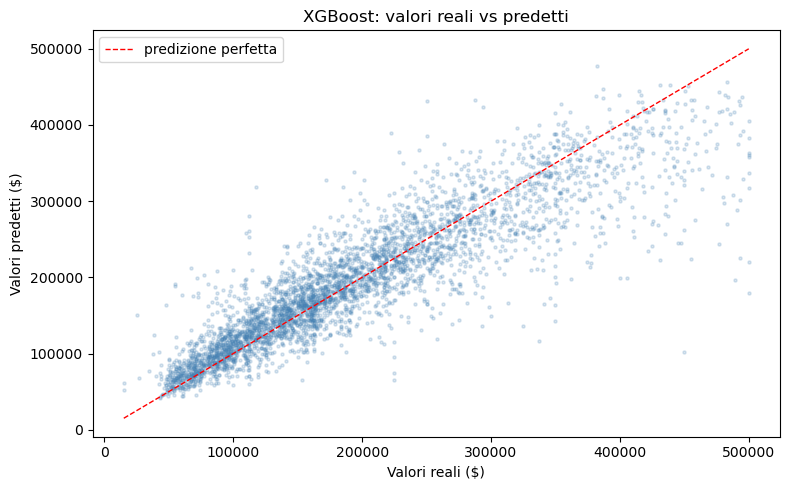

In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_xgb, alpha=0.2, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=1, linestyle="--", label="predizione perfetta")
plt.xlabel("Valori reali ($)")
plt.ylabel("Valori predetti ($)")
plt.title("XGBoost: valori reali vs predetti")
plt.legend()
plt.tight_layout()
plt.show()

## Confronto tra i modelli

I tre grafici confrontano visivamente le metriche di valutazione dei modelli
addestrati. XGBoost (in rosso) si distingue nettamente dai tre modelli lineari
(in blu) su tutte le metriche:

- **R²**: XGBoost raggiunge 0.80 contro 0.61 dei modelli lineari, spiegando
  una quota molto maggiore della varianza del target
- **RMSE**: l'errore medio scende da circa 62.500 dollari a 44.900 dollari, un miglioramento
  di quasi 18.000$ per predizione
- **Errore relativo**: dal 28% circa dei modelli lineari al 17.5% di XGBoost

I tre modelli lineari (regressione lineare, Ridge e Lasso) producono risultati
praticamente identici tra loro, confermando che la regolarizzazione non apporta
benefici significativi su questo dataset e che il vero limite è la natura
non lineare del problema.

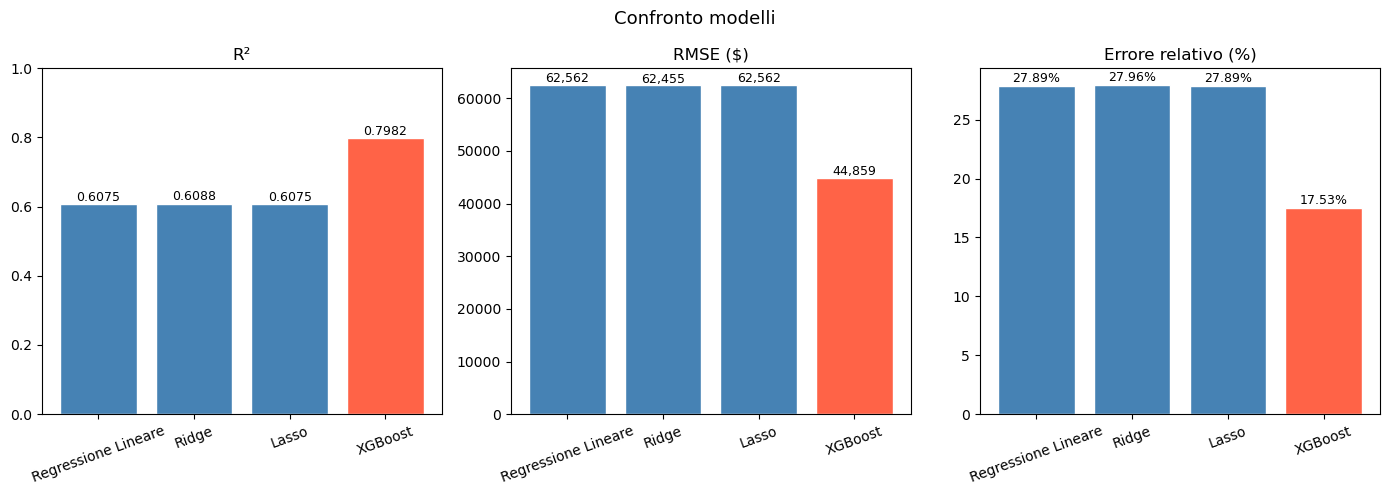

In [41]:
modelli = ["Regressione Lineare", "Ridge", "Lasso", "XGBoost"]

r2_scores   = [round(r2, 4), round(r2_ridge, 4), round(r2_lasso_best, 4), round(r2_xgb, 4)]
rmse_scores = [rmse, rmse_ridge, rmse_lasso_best, rmse_xgb]
err_rel     = [round(errore_relativo, 2), round(errore_relativo_ridge, 2), round(errore_relativo_lasso_best, 2), round(errore_relativo_xgb, 2)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ["steelblue", "steelblue", "steelblue", "tomato"]

axes[0].bar(modelli, r2_scores, color=colors, edgecolor="white")
axes[0].set_title("R²")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, str(v), ha="center", fontsize=9)

axes[1].bar(modelli, rmse_scores, color=colors, edgecolor="white")
axes[1].set_title("RMSE ($)")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 500, f"{v:,.0f}", ha="center", fontsize=9)

axes[2].bar(modelli, err_rel, color=colors, edgecolor="white")
axes[2].set_title("Errore relativo (%)")
axes[2].tick_params(axis="x", rotation=20)
for i, v in enumerate(err_rel):
    axes[2].text(i, v + 0.3, f"{v}%", ha="center", fontsize=9)

plt.suptitle("Confronto modelli", fontsize=13)
plt.tight_layout()
plt.show()

## Ricerca degli iperparametri: Randomized Search su XGBoost

A differenza di Ridge e Lasso che hanno un solo iperparametro (`alpha`),
XGBoost ne ha molti: `n_estimators`, `max_depth`, `learning_rate`,
`subsample`, `colsample_bytree` e `min_child_weight`. Una grid search
esaustiva su tutte le combinazioni sarebbe computazionalmente proibitiva,
quindi si utilizza la **Randomized Search**, che campiona casualmente
**50 combinazioni** dallo spazio degli iperparametri e seleziona quella
che massimizza l'R² tramite cross-validation a 5 fold.

In [45]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [3, 4, 5, 6, 7, 8],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight":  [1, 3, 5, 7],
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="r2",
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)

print(f"Migliori iperparametri: {random_search.best_params_}")
print(f"Miglior R² (cross-validation): {random_search.best_score_:.4f}")

y_pred_xgb_best = random_search.best_estimator_.predict(X_test)

mse_xgb_best = mean_squared_error(y_test, y_pred_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
r2_xgb_best = r2_score(y_test, y_pred_xgb_best)
errore_relativo_xgb_best = np.mean(np.abs((y_test - y_pred_xgb_best) / y_test)) * 100

print(f"\nMetriche sul test set:")
print(f"MSE:              {mse_xgb_best:,.2f}")
print(f"RMSE:             {rmse_xgb_best:,.2f}")
print(f"R²:               {r2_xgb_best:.4f}")
print(f"Errore relativo:  {errore_relativo_xgb_best:.2f}%")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Migliori iperparametri: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Miglior R² (cross-validation): 0.8153

Metriche sul test set:
MSE:              1,796,555,549.95
RMSE:             42,385.79
R²:               0.8198
Errore relativo:  16.01%


## Interpretazione dei risultati: Randomized Search su XGBoost

| Metrica | Valore |
|---|---|
| Miglior R² (cross-validation) | 0.8153 |
| MSE (test set) | 1.796.555.549,95 |
| RMSE (test set) | 42.385,79 $ |
| R² (test set) | 0.8198 |
| Errore relativo (test set) | 16.01% |

### Migliori iperparametri trovati

| Iperparametro | Valore |
|---|---|
| n_estimators | 500 |
| max_depth | 7 |
| learning_rate | 0.05 |
| subsample | 0.9 |
| colsample_bytree | 0.8 |
| min_child_weight | 1 |

La randomized search migliora ulteriormente XGBoost rispetto alla
configurazione di default: l'R² sale da 0.80 a **0.82** e l'errore
medio scende da 44.859$ a **42.386** per casa. Il modello ottimale
utilizza 500 alberi con un learning rate più basso (0.05), il che
significa che ogni albero contribuisce in modo più conservativo ma
il modello complessivo è più preciso.

# Conclusioni finali

Il progetto ha affrontato un problema di **regressione supervisionata**
applicato al dataset California Housing, con l'obiettivo di predire il
valore mediano delle case (`median_house_value`) a partire da feature
geografiche, demografiche e abitative.

### Preprocessing

Prima di addestrare i modelli, il dataset ha richiesto diverse operazioni
di pulizia. I 207 valori nulli presenti in `total_bedrooms` sono stati
imputati con la mediana della colonna, scelta più robusta rispetto alla
media in presenza di distribuzioni asimmetriche. I valori cappati
artificialmente a 500.001$ in `median_house_value` sono stati rimossi
poiché il loro valore reale è ignoto e avrebbero introdotto distorsione
nel target. La variabile categorica `ocean_proximity` è stata convertita
tramite one-hot encoding in 4 dummy variables, escludendo la categoria
`ISLAND` assente nel dataset. Infine tutte le feature sono state
normalizzate nell'intervallo [0, 1] tramite MinMaxScaler.

### Analisi esplorativa

L'EDA ha evidenziato che `median_income` è la feature più correlata con
il target (correlazione ~0.69), confermata sia dalla matrice di correlazione
che dallo scatter plot. È stata inoltre identificata una
forte multicollinearità tra `total_rooms`, `total_bedrooms`, `households`
e `population`, tutte variabili che descrivono la densità abitativa di
un blocco.

### Modelli e risultati

| Modello | R² | RMSE ($) | Errore relativo |
|---|---|---|---|
| Regressione Lineare | 0.61 | 62.562 | 27.89% |
| Ridge (Grid Search) | 0.61 | 62.455 | 27.96% |
| Lasso (Grid Search) | 0.61 | 62.562 | 27.89% |
| XGBoost (default) | 0.80 | 44.859 | 17.53% |
| XGBoost (Randomized Search) | 0.82 | 42.386 | 16.01% |

I tre modelli lineari producono risultati sostanzialmente equivalenti:
la regolarizzazione L1 e L2 non apporta miglioramenti significativi e
nessuna feature viene azzerata da Lasso, segno che tutte le variabili
contribuiscono alla predizione. Il limite comune è l'incapacità di
catturare relazioni non lineari tra le feature e il target.

XGBoost si dimostra nettamente superiore, con un R² di 0.82 nella
configurazione ottimizzata tramite randomized search. La feature
importance indica `ocean_proximity_INLAND` e `median_income` come i
predittori più rilevanti, confermando che la posizione geografica e
il reddito del quartiere sono i principali determinanti del valore
delle case in California.